In [3]:
import pandas as pd
import holidays
import os

PATH = "../data/raw/"

#Chargement de tables Olist
orders = pd.read_csv(os.path.join(PATH, "olist_orders_dataset.csv"))
reviews = pd.read_csv(os.path.join(PATH, "olist_order_reviews_dataset.csv"))
customers = pd.read_csv(os.path.join(PATH, "olist_customers_dataset.csv"))
items = pd.read_csv(os.path.join(PATH, "olist_order_items_dataset.csv"))
products = pd.read_csv(os.path.join(PATH, "olist_products_dataset.csv"))
payments = pd.read_csv(os.path.join(PATH, "olist_order_payments_dataset.csv"))
sellers = pd.read_csv(os.path.join(PATH, "olist_sellers_dataset.csv"))
geo = pd.read_csv(os.path.join(PATH, "olist_geolocation_dataset.csv"))
translation = pd.read_csv(os.path.join(PATH, "product_category_name_translation.csv"))

#Chargement de la source externe 
economy = pd.read_excel(os.path.join(PATH, "Cities_Brazil_IBGE.xlsx"))

all_dfs = {
    "Orders": orders, "Reviews": reviews, "Customers": customers,
    "Items": items, "Products": products, "Payments": payments,
    "Sellers": sellers, "Geo": geo, "Translation": translation,
    "IBGE_Economy": economy
}

for name, df in all_dfs.items():
    print(f"{name:15} | Lignes: {df.shape[0]:<10} | Colonnes: {df.shape[1]}")

print("\n--- TOUTES LES SOURCES SONT PRÊTES POUR L'AUDIT ---")

Orders          | Lignes: 99441      | Colonnes: 8
Reviews         | Lignes: 99224      | Colonnes: 7
Customers       | Lignes: 99441      | Colonnes: 5
Items           | Lignes: 112650     | Colonnes: 7
Products        | Lignes: 32951      | Colonnes: 9
Payments        | Lignes: 103886     | Colonnes: 5
Sellers         | Lignes: 3095       | Colonnes: 4
Geo             | Lignes: 1000163    | Colonnes: 5
Translation     | Lignes: 71         | Colonnes: 2
IBGE_Economy    | Lignes: 5570       | Colonnes: 14

--- TOUTES LES SOURCES SONT PRÊTES POUR L'AUDIT ---


In [4]:
#Audit des Valeurs Manquantes 
print(" ANALYSE DES VALEURS MANQUANTES (en %)")
for name, df in all_dfs.items():
    null_pct = df.isnull().mean() * 100
    if null_pct.sum() > 0:
        print(f"\n--- {name} ---")
        print(null_pct[null_pct > 0].round(2))

# Audit des Doublons
print("\n\n ANALYSE DES DOUBLONS")
for name, df in all_dfs.items():
    dup_count = df.duplicated().sum()
    print(f"{name:15} | Doublons détectés : {dup_count}")

 ANALYSE DES VALEURS MANQUANTES (en %)

--- Orders ---
order_approved_at                0.16
order_delivered_carrier_date     1.79
order_delivered_customer_date    2.98
dtype: float64

--- Reviews ---
review_comment_title      88.34
review_comment_message    58.70
dtype: float64

--- Products ---
product_category_name         1.85
product_name_lenght           1.85
product_description_lenght    1.85
product_photos_qty            1.85
product_weight_g              0.01
product_length_cm             0.01
product_height_cm             0.01
product_width_cm              0.01
dtype: float64

--- IBGE_Economy ---
IDHM    0.11
dtype: float64


 ANALYSE DES DOUBLONS
Orders          | Doublons détectés : 0
Reviews         | Doublons détectés : 0
Customers       | Doublons détectés : 0
Items           | Doublons détectés : 0
Products        | Doublons détectés : 0
Payments        | Doublons détectés : 0
Sellers         | Doublons détectés : 0
Geo             | Doublons détectés : 261831
Translat

In [6]:
# Traitement des doublons Geo 
geo_clean = geo.drop_duplicates(subset=['geolocation_zip_code_prefix']).copy()

# Imputation des catégories de produits manquantes
products['product_category_name'] = products['product_category_name'].fillna('unknown')

# Suppression des commandes sans date de livraison (Inutilisables pour le retard)
orders_clean = orders.dropna(subset=['order_delivered_customer_date']).copy()

print(f"Audit Clean : Geo ({len(geo_clean)} lignes), Orders ({len(orders_clean)} lignes)")

Audit Clean : Geo (19015 lignes), Orders (96476 lignes)


In [5]:
# Conversion des colonnes en format Datetime 
date_columns = [
    'order_purchase_timestamp', 'order_approved_at', 
    'order_delivered_carrier_date', 'order_delivered_customer_date', 
    'order_estimated_delivery_date'
]

for col in date_columns:
    orders[col] = pd.to_datetime(orders[col])

# Vérification de la cohérence logique
# Une livraison ne peut pas arriver avant l'achat.
ghost_data = orders[orders['order_delivered_customer_date'] < orders['order_purchase_timestamp']]
print(f"Nombre de commandes 'fantômes' (livrées avant achat) : {len(ghost_data)}")

# 3. Vérification des Trous de liaison
# Est-ce que toutes les commandes ont des articles 
orders_without_items = orders[~orders['order_id'].isin(items['order_id'])]
print(f"Commandes sans aucun article associe : {len(orders_without_items)}")

Nombre de commandes 'fantômes' (livrées avant achat) : 0
Commandes sans aucun article associe : 775


In [7]:
# Résolution de la granularité : On agrège la table Items par commande
# Pour n'avoir qu'une seule ligne par commande dans notre base finale.
items_agg = items.groupby('order_id').agg({
    'price': 'sum',               
    'freight_value': 'sum',       
    'product_id': 'count'        
}).rename(columns={'product_id': 'qty_items'}).reset_index()

# Fusion des tables Olist (Coeur du projet)
# On utilise un 'inner' join pour Items afin d'éliminer automatiquement les 775 commandes sans articles
master = orders_clean.merge(reviews[['order_id', 'review_score']], on='order_id', how='left')
master = master.merge(customers[['customer_id', 'customer_city', 'customer_state']], on='customer_id', how='left')
master = master.merge(items_agg, on='order_id', how='inner') 

# Préparation et Fusion avec la Source 3 (IBGE Economy)
master['customer_city'] = master['customer_city'].str.lower().str.strip()
economy['LocalCidade'] = economy['LocalCidade'].str.lower().str.strip()

master = master.merge(
    economy[['LocalCidade', 'LocalUF', 'Pib_2014', 'PopEstimada_2018']], 
    left_on=['customer_city', 'customer_state'], 
    right_on=['LocalCidade', 'LocalUF'], 
    how='left'
)

# Ajout de la Source 2 : Jours Fériés (Holidays)
br_holidays = holidays.Brazil()
master['is_holiday'] = master['order_purchase_timestamp'].dt.date.apply(lambda x: x in br_holidays).astype(int)

# Création de la Cible 
master['is_late'] = (master['order_delivered_customer_date'] > master['order_estimated_delivery_date']).astype(int)

# Suppression des colonnes de jointure inutiles
master = master.drop(columns=['LocalCidade', 'LocalUF'])

# Sauvegarde du travail 
master.to_csv("../data/processed/master_data.csv", index=False)

print(f"Phase 2 terminee avec succes")
print(f"Dimensions du Master Dataset : {master.shape[0]} lignes et {master.shape[1]} colonnes.")
print(f"Taux de retard réel (is_late) : {master['is_late'].mean():.2%}")
print(f"Couverture PIB (données non nulles) : {master['Pib_2014'].notna().mean():.2%}")

Phase 2 terminee avec succes
Dimensions du Master Dataset : 97005 lignes et 18 colonnes.
Taux de retard réel (is_late) : 8.11%
Couverture PIB (données non nulles) : 99.12%


### Évaluation des Biais et Cohérence
*   **Données manquantes structurelles :** Environ 3% des commandes n'ont pas de date de livraison réelle.Nous avons choisi de les exclure pour garantir la fiabilité du calcul des retards.
*   **Données Fantômes :** L'audit de cohérence temporelle affiche 0 erreur (aucune livraison avant achat). La chronologie du dataset est saine.
*   **Biais Géographique :** On observe une hyper-concentration sur l'État de São Paulo (SP). Le modèle devra prendre en compte cette disparité spatiale pour ne pas biaiser les prédictions vers les zones urbaines uniquement.

### Dictionnaire de Données (Extraits principaux)

| Nom de la colonne | Type | Description | Source | Valeurs |
| :--- | :--- | :--- | :--- | :--- |
| `order_id` | Object | Identifiant unique de commande | Olist_Orders | UUID |
| `is_late` | Int (0/1) | Cible (Target) : 1 si livraison réelle > estimée | Calculé | 0, 1 |
| `review_score` | Int | Note de satisfaction client | Olist_Reviews | 1 à 5 |
| `product_category_name` | String | Catégorie du produit | Olist_Products | 74 types |
| `is_holiday` | Int (0/1) | 1 si la commande est passée un jour férié | Holidays Lib | 0, 1 |
| `Pib_2014` | Float | PIB de la ville du client | IBGE_Economy | Numérique |

In [4]:
import pandas as pd
import numpy as np

num_cols = ['price', 'freight_value', 'qty_items', 'review_score', 'Pib_2014', 'PopEstimada_2018']

# On force Pib_2014 en numérique.
df['Pib_2014'] = pd.to_numeric(df['Pib_2014'], errors='coerce')

# 3. CALCUL DES STATISTIQUES
stats_table = df[num_cols].describe().T

# Ajout de l'asymétrie
stats_table['skewness'] = df[num_cols].skew()
print("statistiques descriptives et asymétrie")
print(stats_table[['mean', '50%', 'std', 'skewness']].rename(columns={'50%': 'median'}).round(2))

statistiques descriptives et asymétrie
                        mean     median         std  skewness
price                 136.89      86.00      208.70      9.89
freight_value          22.78      17.17       21.53     12.26
qty_items               1.14       1.00        0.54      7.56
review_score            4.16       5.00        1.29     -1.48
Pib_2014            35363.34   27019.00    30677.10      4.41
PopEstimada_2018  2847542.17  471888.00  4371521.87      1.44


### Synthèse des Statistiques Descriptives et de l'Asymétrie

1. **Écart Moyenne/Médiane (Outliers) :**
   * Pour le **Prix** (136 vs 86 BRL) et les **Frais de port** (22 vs 17 BRL), la moyenne est bien supérieure à la médiane.
   * **Conclusion :** Cela confirme la présence de valeurs extrêmes (commandes très chères) qui tirent la moyenne vers le haut.

2. **Forte Volatilité (Écart-type) :**
   * L'écart-type du **Prix** (208.70) est supérieur à sa moyenne. 
   * **Conclusion :** Les données sont très dispersées. La plateforme vend aussi bien des petits articles que des produits de luxe.

3. **Diagnostic de l'Asymétrie (Skewness) :**
   * **Positive (>0) :** `price` (9.89) et `freight_value` (12.26). La distribution a une longue queue à droite (peu de gros montants).
   * **Négative (<0) :** `review_score` (-1.48). La majorité des notes sont à 5/5, la distribution est écrasée vers le haut.

**Décision technique :** La forte asymétrie des variables financières (Prix/PIB) imposera une normalisation (type Log) en Phase 4 pour ne pas biaiser l'apprentissage automatique.

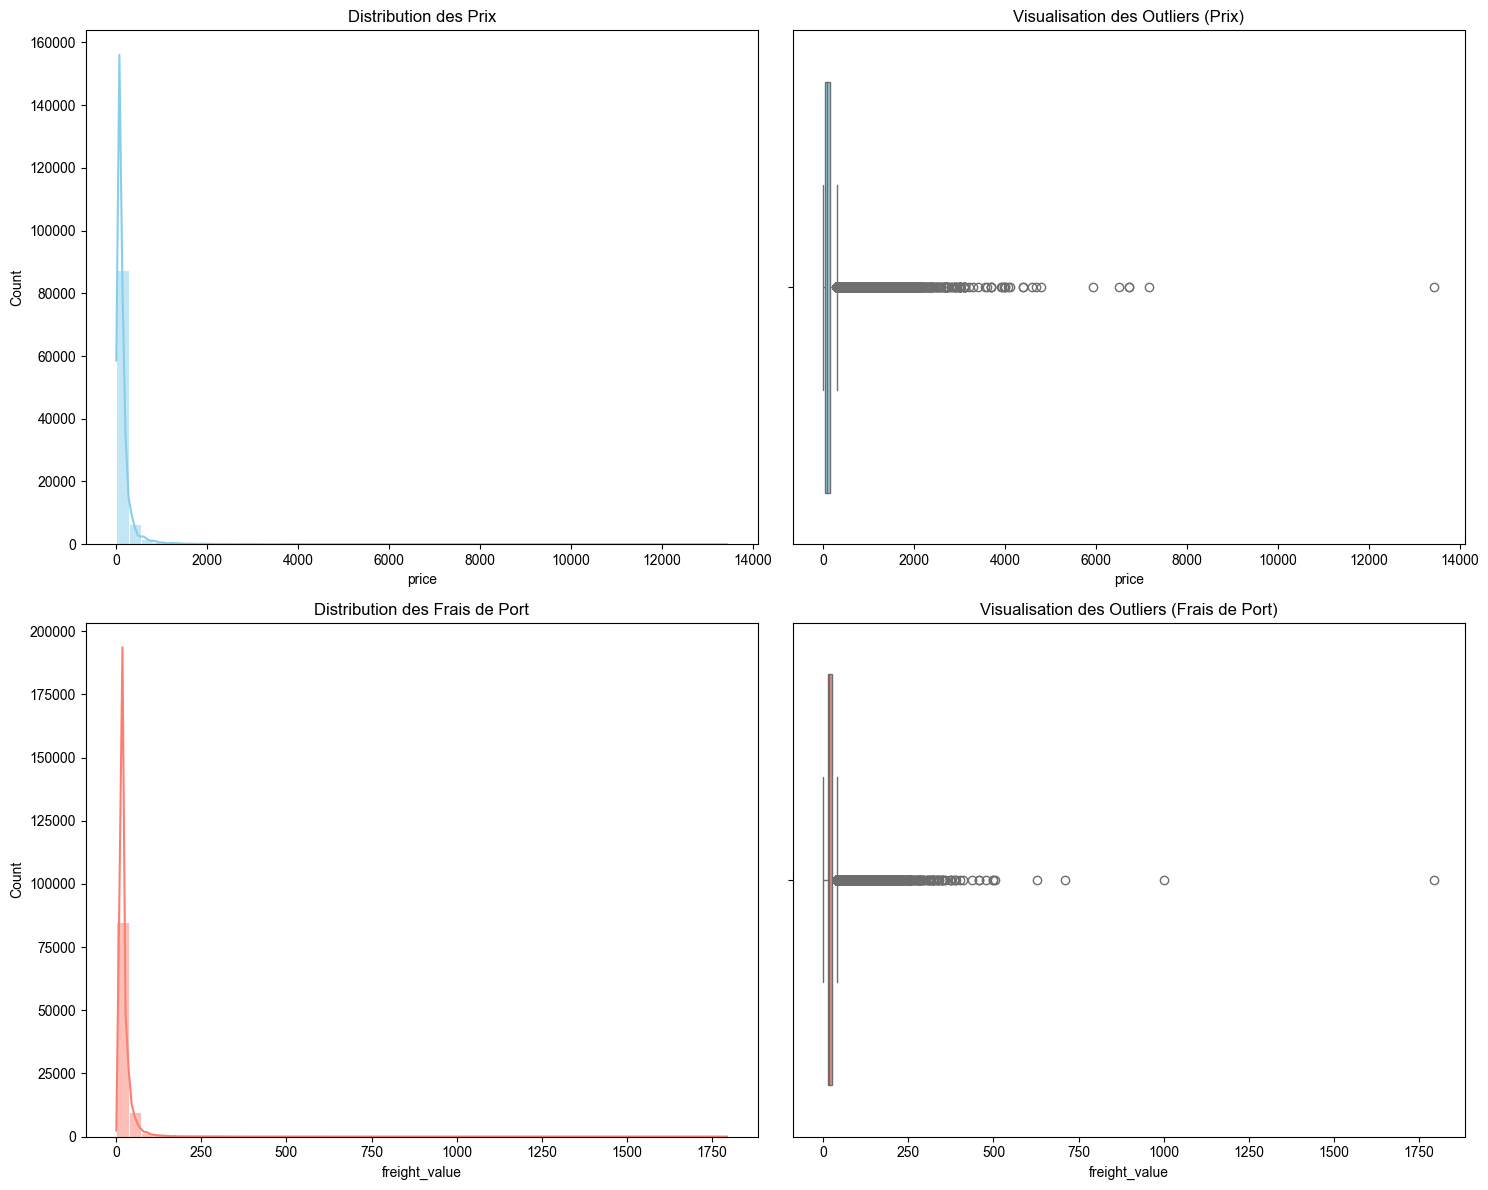

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
sns.set_style("whitegrid")

#  Histogramme du Prix 
sns.histplot(df['price'], bins=50, kde=True, ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Distribution des Prix')

# Boxplot du Prix (Outliers)
sns.boxplot(x=df['price'], ax=axes[0, 1], color='skyblue')
axes[0, 1].set_title('Visualisation des Outliers (Prix)')

# Histogramme des Frais de port
sns.histplot(df['freight_value'], bins=50, kde=True, ax=axes[1, 0], color='salmon')
axes[1, 0].set_title('Distribution des Frais de Port')

# Boxplot des Frais de port
sns.boxplot(x=df['freight_value'], ax=axes[1, 1], color='salmon')
axes[1, 1].set_title('Visualisation des Outliers (Frais de Port)')

plt.tight_layout()
plt.show()

### Visualisation des Distributions et des Valeurs Aberrantes (Outliers)

L'analyse graphique confirme visuellement l'asymétrie extrême calculée précédemment :

1. **Analyse du Prix (Price) :**
   * **Distribution :** L'histogramme montre une forme en "L" (longue traîne). Plus de 95% des produits coûtent moins de 500 BRL, mais l'échelle s'étend jusqu'à plus de 13 000 BRL.
   * **Outliers :** Le boxplot révèle une densité massive de points au-delà des moustaches. Ce ne sont pas des erreurs de saisie, mais des articles de luxe ou des commandes groupées.

2. **Analyse des Frais de Port (Freight Value) :**
   * **Distribution :** Très similaire au prix, avec une concentration forte autour de 15-20 BRL.
   * **Outliers :** On observe des frais de port dépassant les 1 500 BRL. Ces valeurs correspondent probablement à des livraisons d'objets lourds vers des régions reculées du Brésil.

**Impact pour la modélisation (Décision d'Ingénieur) :**
* La présence de ces "Extreme Outliers" peut perturber l'apprentissage de certains modèles (comme la Régression Logistique) en leur donnant trop d'importance.
* **Action future :** Une transformation logarithmique ou un "Capping" (tronquage) des valeurs extrêmes sera testé en Phase 4 pour stabiliser les calculs.

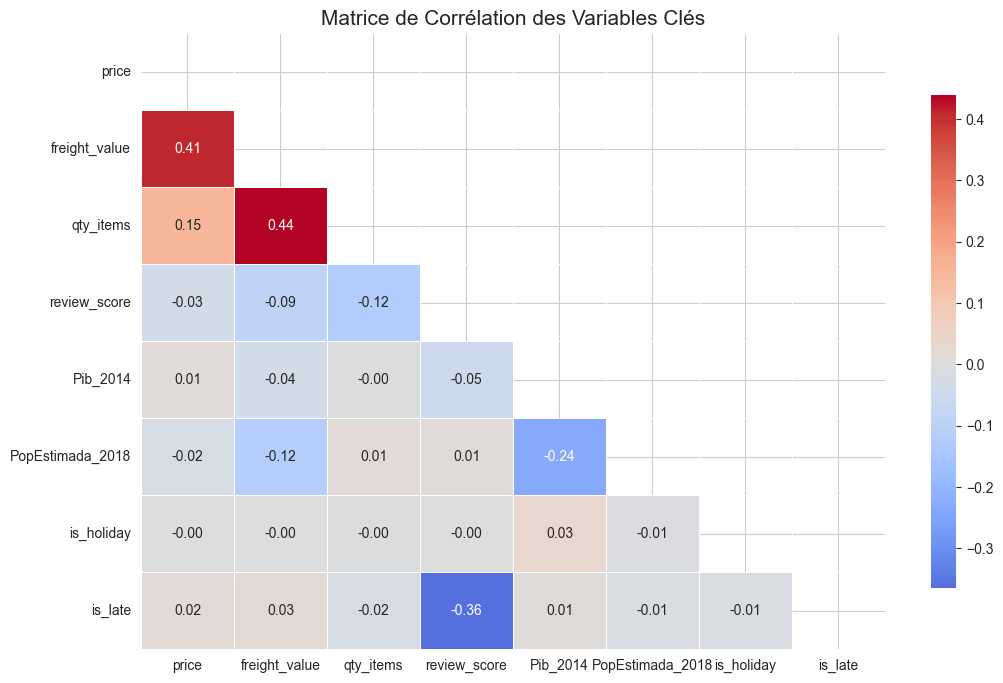

In [6]:
import numpy as np

# Sélection des variables pour la corrélation
corr_cols = ['price', 'freight_value', 'qty_items', 'review_score', 
             'Pib_2014', 'PopEstimada_2018', 'is_holiday', 'is_late']

# Calcul de la matrice de corrélation
corr_matrix = df[corr_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Affichage de la Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', 
            center=0, linewidths=.5, cbar_kws={"shrink": .8})

plt.title('Matrice de Corrélation des Variables Clés', fontsize=15)
plt.show()

### Analyse des Corrélations (Heatmap)

La matrice de corrélation de Pearson nous permet de valider nos hypothèses métier et de préparer la sélection des variables pour le modèle d'IA :

#### 1. Validation du Proxy de Churn (Le point clé)
*   **is_late vs review_score (-0.36) :** C'est la corrélation la plus forte de la cible. Le signe négatif confirme que les retards de livraison sont un moteur majeur de l'insatisfaction client. 
*   *Interprétation :* Une commande en retard dégrade statistiquement la note de satisfaction, validant notre choix d'utiliser cette métrique comme indicateur de perte de client (Churn).

#### 2. Relations Logistiques et Commerciales
*   **price / freight_value (0.41) et qty_items / freight_value (0.44) :** On observe une corrélation positive logique. Plus une commande contient d'articles ou des produits chers (souvent plus volumineux), plus les frais de port augmentent.
*   Ces variables sont liées mais pas redondantes (corrélation < 0.80), nous pouvons donc les conserver toutes pour l'entraînement.

#### 3. Analyse des variables externes (PIB & Population)
*   Les variables socio-économiques montrent une corrélation très faible avec les autres variables (proche de 0).
*   Cela signifie que la richesse d'une ville (PIB) n'influe pas directement sur le prix des produits achetés, mais elle apporte une information orthogonale qui pourrait aider le modèle à mieux comprendre les contextes de livraison locaux.

**Conclusion Technique :** L'absence de corrélation supérieure à 0.80 garantit l'absence de **multicolinéarité** majeure, ce qui stabilisera l'apprentissage de nos futurs modèles de classification.

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_15852\1264840582.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=holiday_analysis.index, y=holiday_analysis.values, palette='cool')


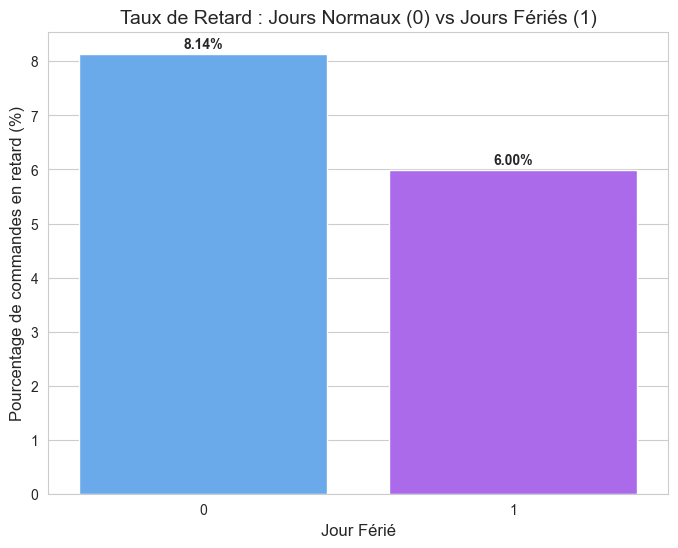

Nombre de commandes passées un jour férié : 1484


In [7]:
# Calcul du taux de retard selon si c'est un jour férié ou non
holiday_analysis = df.groupby('is_holiday')['is_late'].mean() * 100

plt.figure(figsize=(8, 6))
sns.barplot(x=holiday_analysis.index, y=holiday_analysis.values, palette='cool')
plt.title('Taux de Retard : Jours Normaux (0) vs Jours Fériés (1)', fontsize=14)
plt.xlabel('Jour Férié', fontsize=12)
plt.ylabel('Pourcentage de commandes en retard (%)', fontsize=12)

for i, val in enumerate(holiday_analysis.values):
    plt.text(i, val + 0.1, f'{val:.2f}%', ha='center', fontweight='bold')

plt.show()

print(f"Nombre de commandes passées un jour férié : {df['is_holiday'].sum()}")

### l'impact des Jours Fériés

Contre toute attente, l'analyse révèle que le taux de retard est **plus faible** lors des commandes passées un jour férié :
*   **Jours Normaux :** 8.14% de retards.
*   **Jours Fériés :** 6.00% de retards.

**Analyse :** 
Ce phénomène suggère que le système de calcul des promesses de livraison d'Olist intègre déjà une "marge de sécurité" supplémentaire lors des jours fériés. Bien que le transport puisse être plus lent, la promesse client est plus large, ce qui mécaniquement réduit le taux de retard technique (`is_late`). 

**Décision pour l'IA :** 
Malgré une corrélation globale faible, cette variable reste un signal pertinent car elle montre un comportement logistique différent.

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_15852\2397530574.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='is_late', y='review_score', data=df, palette='muted', inner='quartile')


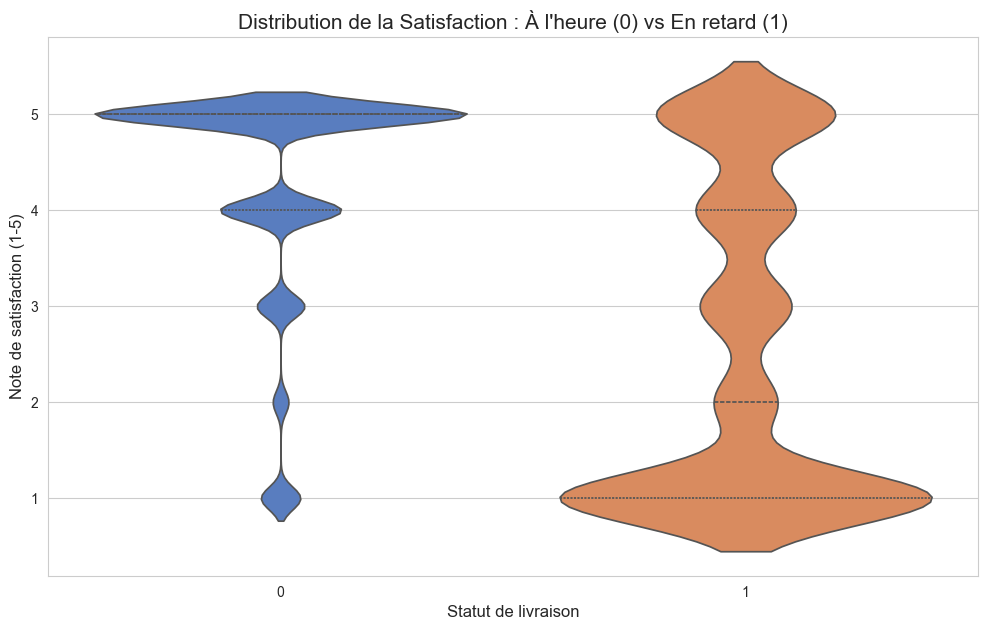

In [8]:
# Création du Violin Plot pour comparer les notes 
plt.figure(figsize=(12, 7))

sns.violinplot(x='is_late', y='review_score', data=df, palette='muted', inner='quartile')
plt.title('Distribution de la Satisfaction : À l\'heure (0) vs En retard (1)', fontsize=15)
plt.xlabel('Statut de livraison', fontsize=12)
plt.ylabel('Note de satisfaction (1-5)', fontsize=12)

plt.show()

### Analyse Comparative de la Satisfaction (Violin Plot)

Ce graphique de type "Violin Plot" permet de visualiser la densité des notes de satisfaction selon le statut de la livraison. Les conclusions sont majeures pour notre étude :

*   **Livraisons à l'heure (Bleu) :** La distribution est fortement concentrée sur la note **5/5**. Le système logistique nominal génère une grande satisfaction client.
*   **Livraisons en retard (Orange) :** On observe un basculement radical de la distribution. La densité maximale se déplace vers la note **1/5**. 
*   **Validation du Proxy Churn :** Le retard de livraison est le facteur principal qui pousse un client d'un état de satisfaction maximale (5) vers une insatisfaction irrémédiable (1 ou 2).

**Impact Décisionnel :** Ce constat confirme l'urgence de notre système d'alerte. Réduire le volume du "violon orange" ou intervenir avant qu'il ne se forme est la clé pour protéger le chiffre d'affaires d'Olist.